##### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

##### Load Test Data

In [2]:
test_df = pd.read_csv("../data/processed/test.csv")

In [4]:
test_df.shape

(15200, 171)

In [5]:
test_df.head()

,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,ag_003,...,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000,class
0,-0.101763,-6.672382e-17,2.293749,-0.005367,-0.042858,-0.053164,-1.010922e-02,-0.022717,-5.585031e-02,-0.111006,...,-0.209908,-2.380616e-01,-2.505123e-01,-0.209612,-0.146392,6.058065e-01,1.232924,-0.021052,-0.021654,0
1,-0.213510,-6.672382e-17,-0.461639,-0.005406,-0.042858,-0.053164,-1.137989e-02,-0.022936,-5.591883e-02,-0.111097,...,-0.382841,-3.727268e-01,-3.472398e-01,-0.306253,-0.201108,-2.940930e-01,-0.169739,-0.021052,-0.021654,0
2,-0.209098,-4.370160e-01,2.293749,-0.005405,-0.042858,-0.053164,-1.137989e-02,-0.022936,-5.591883e-02,-0.111097,...,-0.378423,-3.652879e-01,-3.340260e-01,-0.290212,-0.197353,-2.930830e-01,-0.169053,-0.021052,-0.021654,0
3,0.748620,-4.370160e-01,-0.461639,-0.005406,1.516210,4.596903,-1.389017e-18,0.000000,-1.038652e-17,0.000000,...,0.000000,-4.813233e-17,5.066850e-17,0.000000,0.000000,-6.123344e-17,0.000000,-0.021052,-0.021654,0
4,-0.196079,-6.672382e-17,2.293749,-0.005404,-0.042858,-0.053164,-1.137989e-02,-0.022936,-5.591883e-02,-0.111097,...,-0.342113,-3.349718e-01,-3.180161e-01,-0.282347,-0.186412,-2.447634e-01,-0.140365,-0.021052,-0.021654,0


##### Separate Features and Target

In [6]:
x_test=test_df.drop(columns=["class"])
y_test=test_df["class"]

In [7]:
x_test.shape,y_test.shape

((15200, 170), (15200,))

##### Load All Models

In [8]:
with open("../artifacts/logistic_regression.pkl", "rb") as file:
    logistic_model = pickle.load(file)

In [9]:
with open("../artifacts/knn.pkl", "rb") as file:
    knn_model = pickle.load(file)

In [10]:
with open("../artifacts/decision_tree.pkl", "rb") as file:
    decision_tree_model = pickle.load(file)

In [11]:
with open("../artifacts/random_forest.pkl", "rb") as file:
    random_forest_model = pickle.load(file)

In [12]:
with open("../artifacts/svm.pkl", "rb") as file:
    svm_model = pickle.load(file)

In [13]:
with open("../artifacts/naive_bayes.pkl", "rb") as file:
    naive_bayes_model = pickle.load(file)

In [14]:
with open("../artifacts/gradient_boosting.pkl", "rb") as file:
    gradient_boosting_model = pickle.load(file)

In [15]:
with open("../artifacts/adaboost.pkl", "rb") as file:
    adaboost_model = pickle.load(file)

In [16]:
with open("../artifacts/xgboost.pkl", "rb") as file:
    xgboost_model = pickle.load(file)

## Logistic Regression Evaluation

In [17]:
logistic_predictions = logistic_model.predict(x_test)

##### Accuracy

In [18]:
logistic_accuracy = accuracy_score(y_test,logistic_predictions)

print("Logistic Regression Accuracy:", logistic_accuracy)

Logistic Regression Accuracy: 0.9745394736842106


##### Precision

In [19]:
logistic_precision = precision_score(y_test, logistic_predictions)

print("Logistic Regression Precision:", logistic_precision)

Logistic Regression Precision: 0.4081967213114754


##### Recall

In [20]:
logistic_recall = recall_score(y_test,logistic_predictions)

print("Logistic Regression Recall:", logistic_recall)

Logistic Regression Recall: 0.9054545454545454


##### F1 Score

In [21]:
logistic_f1 = f1_score(y_test,logistic_predictions)

print("Logistic Regression F1 Score:", logistic_f1)

Logistic Regression F1 Score: 0.5627118644067797


##### Classification Report

In [22]:
print( classification_report(y_test,logistic_predictions ))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     14925
           1       0.41      0.91      0.56       275

    accuracy                           0.97     15200
   macro avg       0.70      0.94      0.77     15200
weighted avg       0.99      0.97      0.98     15200



##### Confusion Matrix

In [23]:
logistic_cm = confusion_matrix(y_test,logistic_predictions)

print(logistic_cm)

[[14564   361]
 [   26   249]]


##### Confusion Matrix Display

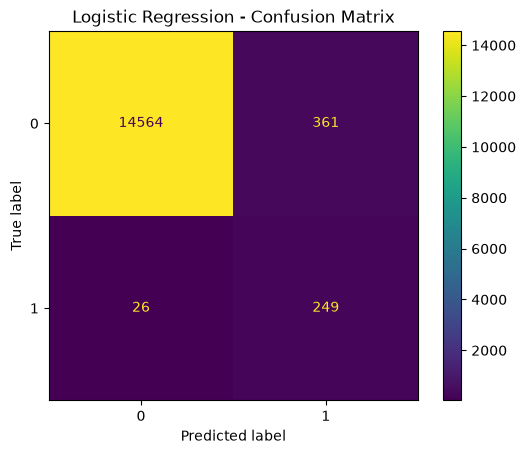

In [24]:
cm = confusion_matrix(y_test, logistic_predictions)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("Logistic Regression - Confusion Matrix")

plt.show()

##### ROC Curve

In [25]:
logistic_probability = logistic_model.predict_proba(x_test)[:, 1]

In [26]:
logistic_fpr, logistic_tpr, logistic_thresholds = roc_curve(y_test,logistic_probability)

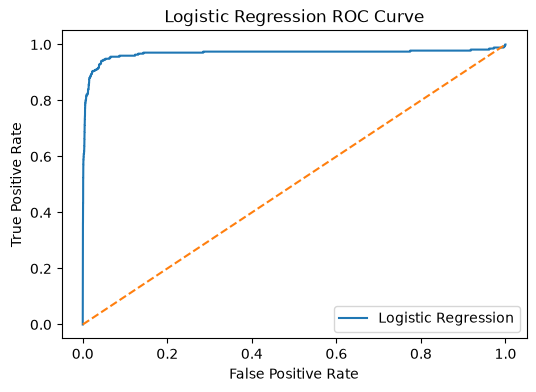

In [27]:
plt.figure(figsize=(6, 4))

plt.plot(
    logistic_fpr,
    logistic_tpr,
    label="Logistic Regression"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Logistic Regression ROC Curve")

plt.legend()

plt.show()

##### ROC-AUC

In [28]:
logistic_roc_auc = roc_auc_score( y_test,logistic_probability)

print("Logistic Regression ROC-AUC:", logistic_roc_auc)

Logistic Regression ROC-AUC: 0.9682142835389066
